In [1]:
import scipy
import networkx as nx #A python library that's helpful when dealing with graphs 
import matplotlib.pyplot as plt



In [2]:
## some useful functions 

##draw the grid graph, can choose to lock the vertices into grid structure 
def draw_graph( graph, position = False, plot_size = (5,5)):

    plt.figure(figsize= plot_size)

    if position == False: 
        
        nx.draw(
        graph,
        with_labels=True,
        node_color="skyblue",
        node_size=600,
        font_size=8,
        font_weight = 'bold',
        edge_color="gray",)

    else: 
        nx.draw(
            graph,
            pos= position,
            with_labels=True,
            node_color="skyblue",
            node_size=600,
            font_size=8,
            font_weight = 'bold',
            edge_color="gray",)      

    plt.show()

#function to determine where each node needs to be for gridlock for a grid defined by integers
def convert_position_to_integers (integer_Graph, cols ):
    pos_int = {}
    for node in integer_Graph.nodes():
        node_mod = node- 1
        col_idx = node_mod % cols
        row_idx = node_mod // cols
        pos_int[node] = (col_idx, -row_idx)
    return pos_int


In [3]:
##perform local complementation on a node using a graph defined by integers
def local_complementation_integers (vertex, Graph, show_graph = False, gridlock = False, plot_size = (3,3), position_int = None):    
    # copy the graph 
    G = Graph.copy()

    #extract neighbor subgraph of vertex 
    neighbors = list(G.neighbors(vertex))
    G_sub = G.subgraph(neighbors)

    #complement the subgraph 
    G_sub_complement = nx.complement(G_sub)
    
    #delete existing edges between neighbors 
    G.remove_edges_from(G_sub.edges())

    #add complement edges between naeighbors
    G.add_edges_from(G_sub_complement.edges())

    #plot graph 
    if show_graph== True:
        if gridlock == False:
            draw_graph(G, plot_size = plot_size)
        else:
            draw_graph(G, position_int, plot_size = plot_size)

    return G    

In [4]:
#Functions for performing Graph Operations/Pauli Measurements
##Each function has the option to draw the resulting graph after performing the operation
def Z_graph_operation(vertex_to_delete, graph_int, show_graph = False, gridlock = False, 
                      plot_size = (3,3), position_int = None): 
    
    G = graph_int.copy()
    
    #delete vertex
    G.remove_node(vertex_to_delete)

    #plot graph 
    if show_graph== True:
        if gridlock == False:
            draw_graph(G, plot_size = plot_size)
        else:
            draw_graph(G, position_int, plot_size = plot_size)

    return G

def Y_graph_operation(vertex_to_delete, graph_int, show_graph = False, gridlock = False, 
                      plot_size = (3,3), position_int = None): 
    
    G = graph_int.copy()

    #perform LC on vertex 
    G = local_complementation_integers(vertex_to_delete, G)
    
    #delete vertex
    G.remove_node(vertex_to_delete)

    #plot graph 
    if show_graph== True:
        if gridlock == False:
            draw_graph(G, plot_size = plot_size)
        else:
            draw_graph(G, position_int, plot_size = plot_size)

    return G


def X_graph_operation(vertex_to_delete, graph_int, pivot = False, show_graph = False, gridlock = False, 
                      plot_size = (3,3), position_int = None): 
    
    neighbors = list(graph_int.neighbors(vertex_to_delete))

    ##check to see if the vertex has any neighbors 
    if not neighbors:
        print ("vertex has no neighbors, unable to perform operation")
        return

    #pick a pivot if unspecified 
    if pivot == False:
        pivot = neighbors[0]
    
    #ensure the pivot choice is a neighbor to the desired vertex 
    if pivot not in neighbors:
        print("pivot is not a neighbor of vertex, unable to perform operation")
        return graph_int
    
    G = graph_int.copy()
    #draw_graph(G, plot_size = plot_size)


    #perform LC's on vertex and pivot  
    G = local_complementation_integers(pivot, G)
    #draw_graph(G, plot_size = plot_size)
    G = local_complementation_integers(vertex_to_delete, G)
    #draw_graph(G, plot_size = plot_size)
    G = local_complementation_integers(pivot, G)
    #draw_graph(G, plot_size = plot_size)
    
    #delete vertex
    G.remove_node(vertex_to_delete)

    #plot graph 
    if show_graph== True:
        if gridlock == False:
            draw_graph(G, plot_size = plot_size)
        else:
            draw_graph(G, position_int, plot_size = plot_size)

    return G

In [5]:
#functions for protocols on 3xn and 2xn grids 

#for a 3xn graph 
def crossing_protocol(vertex_a, graph_int, cols, pivot = False, show_graph = False, gridlock = False, 
                      plot_size = (3,3), position_int = None): 
    
    neighbors = list(graph_int.neighbors(vertex_a))

    #check to see if vertex a is a valid choice
    required_neighbors = [vertex_a - cols, vertex_a -1, vertex_a + 1, vertex_a + cols]
    for neighbor in required_neighbors:
        if neighbor not in neighbors:
            print ("vertex a is not not a valid option, please pick another vertex.")
            return

    G = graph_int.copy()

    #perform X measurement on vertex a using a-n as the pivot 
    G= X_graph_operation(vertex_a, graph_int, pivot = vertex_a-cols, show_graph= True, gridlock = True, plot_size= (10,3), position_int= pos_int)
    
    #perform vertex deletions 
    G = Z_graph_operation( vertex_a-cols,G )
    G = Z_graph_operation( vertex_a+cols,G )
    
    #plot graph 
    if show_graph== True:
        if gridlock == False:
            draw_graph(G, plot_size = plot_size)
        else:
            draw_graph(G, position_int, plot_size = plot_size)

    return G


# for a 3xn graph
def flipping_protocol(graph_int, cols, show_graph = False, gridlock = False, 
                      plot_size = (3,3), position_int = None): 
    
    #check to see if grid is sufficiently large 
    if cols < 4:
        print ("Grid is not large enough.")
        return

    G = graph_int.copy()

    #perform X and Z measurements 
    G =  X_graph_operation( cols -1, G, pivot= cols )
    G =  X_graph_operation( 2*cols -1, G, pivot= 3*cols-1 )
    G = Z_graph_operation( 3*cols-1 ,G )

    #perform LC's
    G = local_complementation_integers( 2*cols ,G )
    G = local_complementation_integers( 3*cols ,G )
    G = local_complementation_integers( 2*cols ,G )

    #perform Y measurements 
    G = Y_graph_operation(cols-2 ,G )
    G = Y_graph_operation(2*cols-2 ,G )
    G = Y_graph_operation(3*cols-2 ,G )

    #plot graph 
    if show_graph== True:
        if gridlock == False:
            draw_graph(G, plot_size = plot_size)
        else:
            draw_graph(G, position_int, plot_size = plot_size)

    return G

# for a 3xn graph
def extract_corners(graph_int, cols, show_graph = False, gridlock = False, 
                      plot_size = (3,3), position_int = None, invert = False): 
    
    #check to see if grid is sufficiently large 
    if cols < 3:
        print ("Grid is not large enough.")
        return

    G = graph_int.copy()

    #perform X Y Z measurements for all n
    if invert == True: 
        G =  Y_graph_operation( 2*cols+2, G)
        G =  X_graph_operation( cols +2, G, pivot= 2 )
        G = Z_graph_operation( 2 ,G )
        G = Y_graph_operation( cols+3 ,G )
        G = Y_graph_operation( 3 ,G )
    else:
        G =  Y_graph_operation( 2, G)
        G =  X_graph_operation( cols +2, G, pivot= 2*cols+2 )
        G = Z_graph_operation( 2*cols+2 ,G )
        G = Y_graph_operation( cols+3 ,G )
        G = Y_graph_operation( 2*cols+3 ,G )

    #if n=3 the protocol is over 
    if cols == 3: 
            #plot graph 
        if show_graph== True:
            if gridlock == False:
                draw_graph(G, plot_size = plot_size)
            else:
                draw_graph(G, position_int, plot_size = plot_size)
    
        return G


    #if n>=4 finish the protocol 
    if invert == True:
        G = Z_graph_operation(cols+4 ,G )
        G = Z_graph_operation(4 ,G )
    else:
        G = Z_graph_operation(cols+4 ,G )
        G = Z_graph_operation(2*cols+4 ,G )

    #plot graph 
    if show_graph== True:
        if gridlock == False:
            draw_graph(G, plot_size = plot_size)
        else:
            draw_graph(G, position_int, plot_size = plot_size)

    return G

#for a 2xn graph 
def corner_folding_protocol( graph_int, cols, show_graph = False, 
                             gridlock = False, plot_size = (3,3), 
                             position_int = None): 
    
    #check to see if grid is sufficiently large
    if cols < 5:
        print("Grid is too small, please pick a 2xn grid with n>4")
        return
        
    G = graph_int.copy()

    #Perform LC's
    G = local_complementation_integers(cols+1, G)
    G = local_complementation_integers(2*cols, G)

    G  = local_complementation_integers(1, G)
    G  = local_complementation_integers(cols, G)

    G = local_complementation_integers(2, G)
    G = local_complementation_integers(cols-1, G)

    #Perform Y measurements
    G = Y_graph_operation(1, G)
    G = Y_graph_operation(cols, G)
    
    G = Y_graph_operation(2, G)
    G = Y_graph_operation(cols-1, G)

    #perform final LC's
    G = local_complementation_integers(cols+1, G)
    G = local_complementation_integers(2*cols, G) 
    
    #plot graph 
    if show_graph== True:
        if gridlock == False:
            draw_graph(G, plot_size = plot_size)
        else:
            draw_graph(G, position_int, plot_size = plot_size)

    return G

In [6]:
#perform the X Protocol on a grid of integers to extract a bell pair. Must specify the desired ordered repeater line
'''built  from protocol described in aisakh Mannalath and Anirban Pathak. Entanglement routing and bottlenecks in grid
networks. Annalen der Physik, 537(5):2400316, 2025.'''

def x_protocol_grid_integers(graph_int, ordered_repeater_line, bell_pair, show_graph = False, gridlock = False, plot_size = (3,3),
                             position_int = None, show_X_measurement = False, gridlock_X = False, show_Z_measurement = False,
                             gridlock_Z = False):
    
    G = graph_int.copy()

    #itratively perform x measurements along the repeater line 
    for i in range (len(ordered_repeater_line)-2):
        #pivots are specified using the following: let V_i be the ith vertex in the repeater line. Then if X(V_1), then pivot = V_0; 
        # if x(v_{n-1}), then pivot = V_n; for any intermeidary, use an adjacent pivot on the repeater line. 
        
        if i == 0: 
            p = ordered_repeater_line[0]
        elif i == len(ordered_repeater_line)-3:
            p = ordered_repeater_line[-1]
        else :
            neighbors = list(G.neighbors(ordered_repeater_line[i+1]))
            pivots = [v for v in neighbors if v in ordered_repeater_line]

            if not pivots:
                raise ValueError(f"No repeater neighbor found for vertex {ordered_repeater_line[i+1]}")
                
            p = pivots[0]
            
        
        G = X_graph_operation(ordered_repeater_line[i+1], G, pivot = p, 
                              show_graph= show_X_measurement, gridlock= gridlock_X, plot_size= plot_size)

    #find all the neighbors of the bell pair 
    neighboring_vertices = list( G.neighbors(bell_pair[0])) + list( G.neighbors(bell_pair[1])) 
    neighboring_vertices = [v for v in neighboring_vertices if v not in bell_pair]

    
    #perform z measurements on all neighbors
    for v in neighboring_vertices: 
        G = Z_graph_operation(v, G, show_graph = show_Z_measurement, gridlock= gridlock_Z, plot_size= plot_size)
  
    #plot graph 
    if show_graph== True:
        if gridlock == False:
            draw_graph(G, plot_size = plot_size)
        else:
            draw_graph(G, position_int, plot_size = plot_size)

    return G

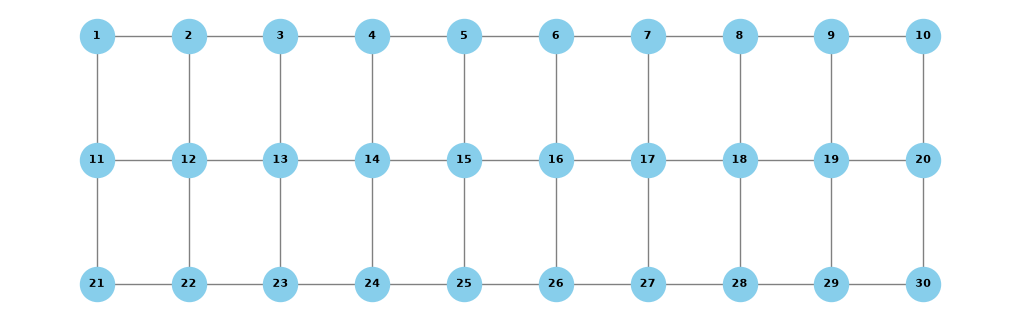

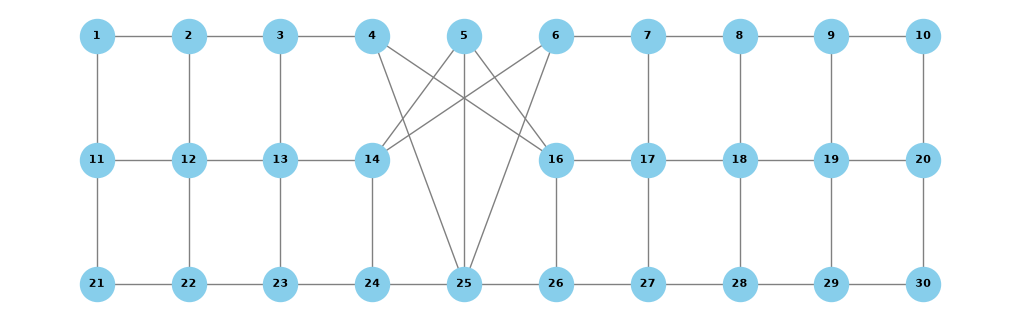

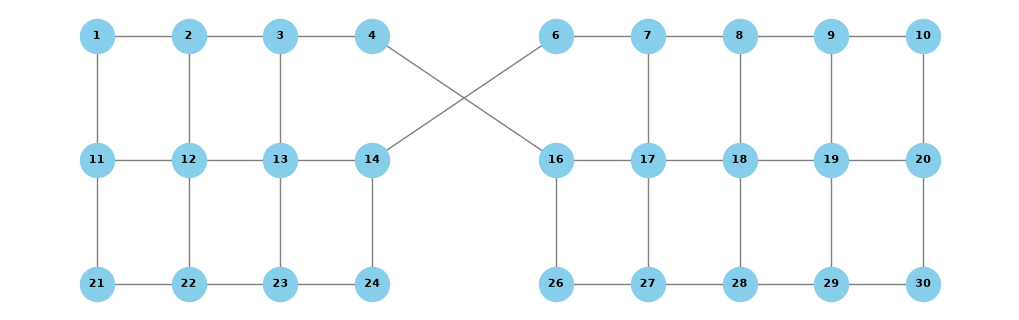

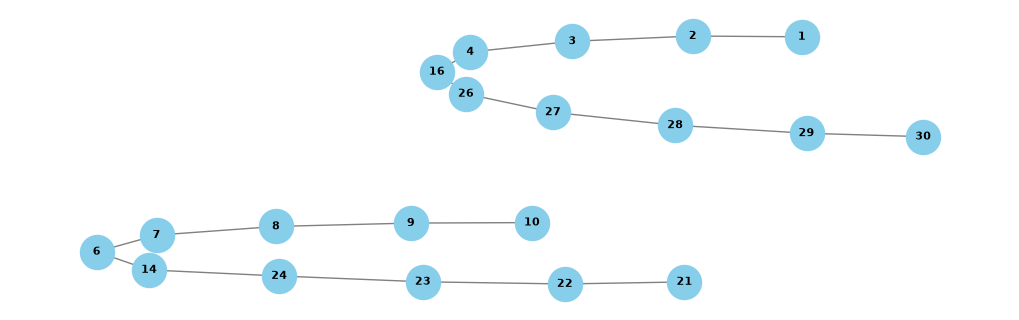

In [7]:
rows = 3
cols = 10

G = nx.grid_2d_graph(rows, cols)

G_int = nx.convert_node_labels_to_integers(G, first_label=1)
pos_int = convert_position_to_integers( G_int, cols)

draw_graph(G_int, pos_int, (10,3))

##crossing protocol 

G_crossing_protocol = crossing_protocol(15, G_int, cols, show_graph= True, gridlock= True, plot_size = (10,3), position_int= pos_int)

vertices = [11,12,13,17,18,19,20]
for vertex in vertices: 
    G_crossing_protocol = Z_graph_operation(vertex, G_crossing_protocol, show_graph= False, gridlock = True, plot_size= (10,3))
draw_graph(G_crossing_protocol, plot_size =(10,3))

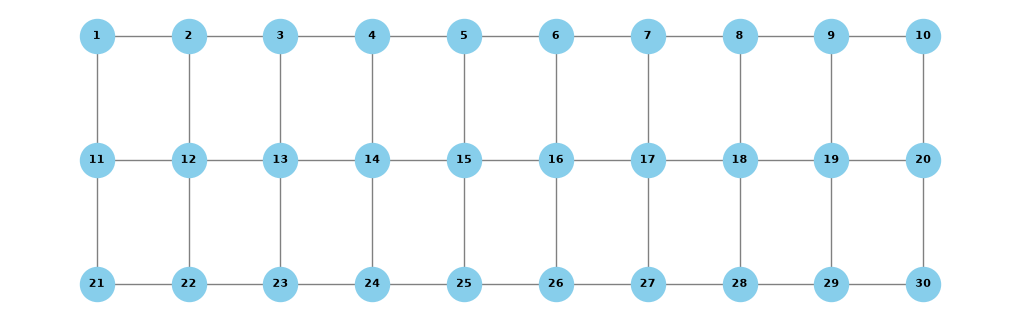

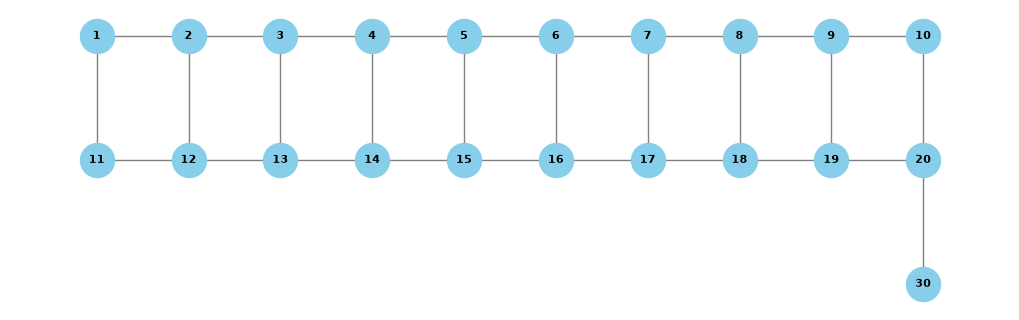

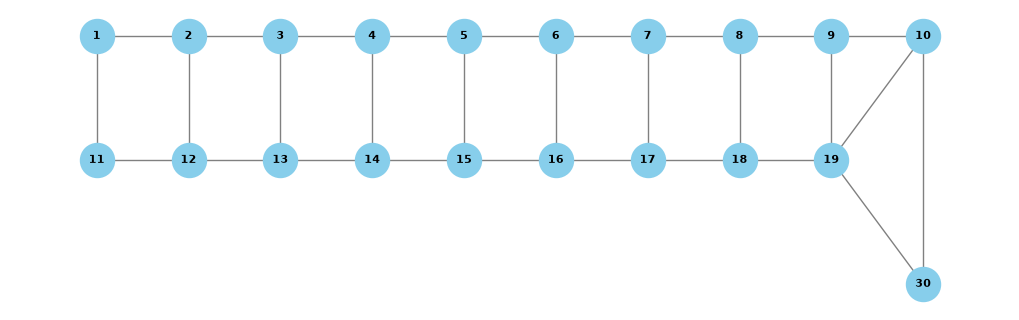

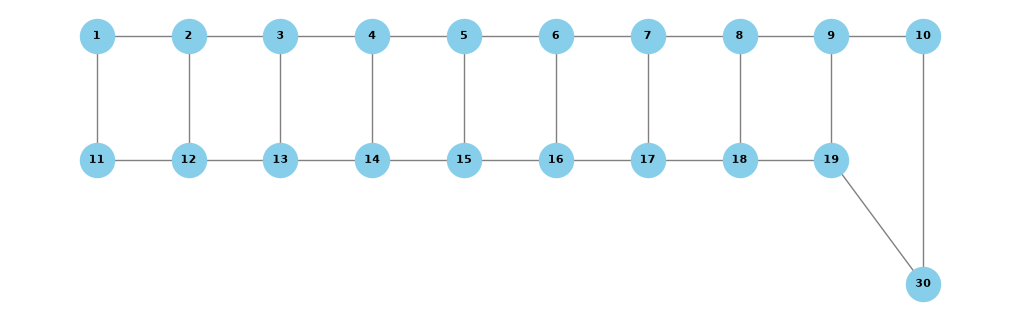

In [8]:
#turn 3xn into 2xn and move corner vertex up 

draw_graph(G_int, pos_int, (10,3))
G1 = G_int
vertices = [21,22,23,24,25,26,27,28,29]
for v in vertices:
    G1 = Z_graph_operation(v, G1, show_graph= False, gridlock= True, position_int = pos_int, plot_size = (10,3))

draw_graph(G1, pos_int, (10,3))

G1 = Y_graph_operation(20, G1, show_graph= True, gridlock= True, position_int = pos_int, plot_size = (10,3))
G1 = local_complementation_integers(30, G1, show_graph= True, gridlock= True, position_int = pos_int, plot_size = (10,3))

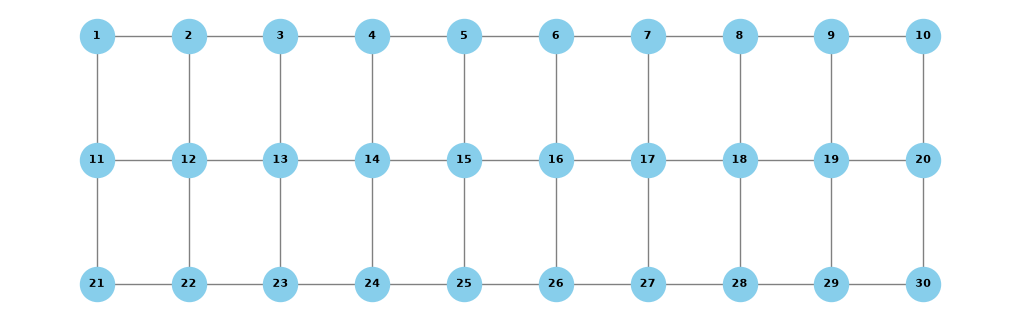

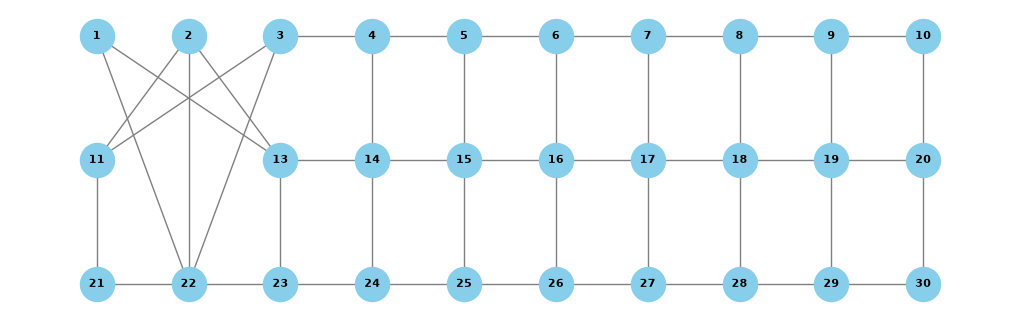

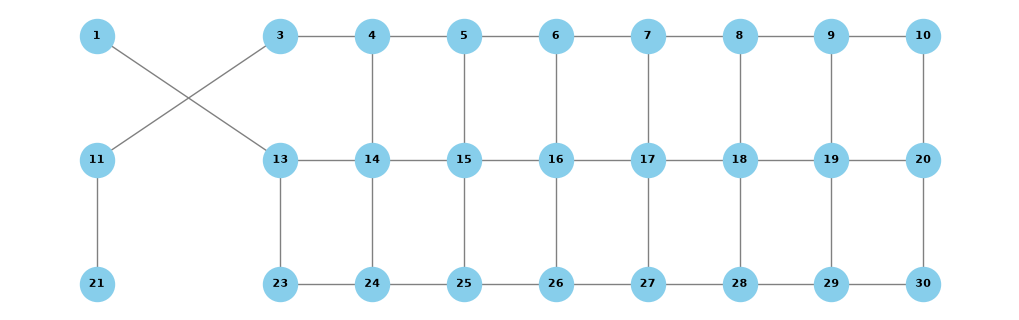

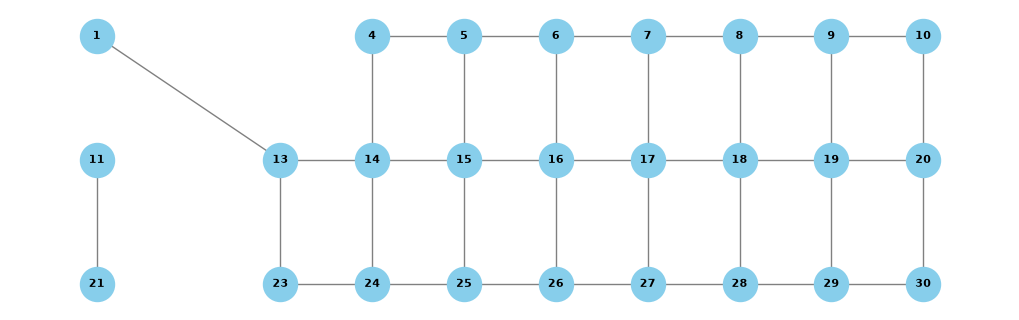

In [9]:
#solution to a 3xn noncrossing side case 
G2 = G_int
draw_graph(G2, pos_int, (10,3))

G2 = crossing_protocol(12, G_int, cols, show_graph= True, gridlock= True, plot_size = (10,3), position_int= pos_int)
G2 = Z_graph_operation(3, G2, show_graph= True, gridlock= True, position_int = pos_int, plot_size = (10,3))

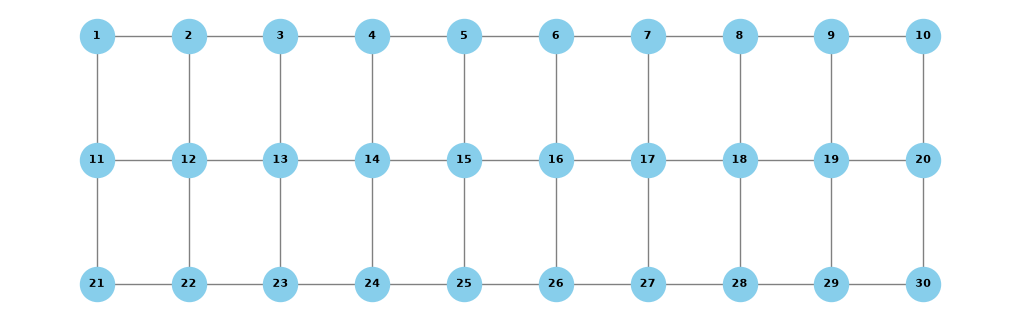

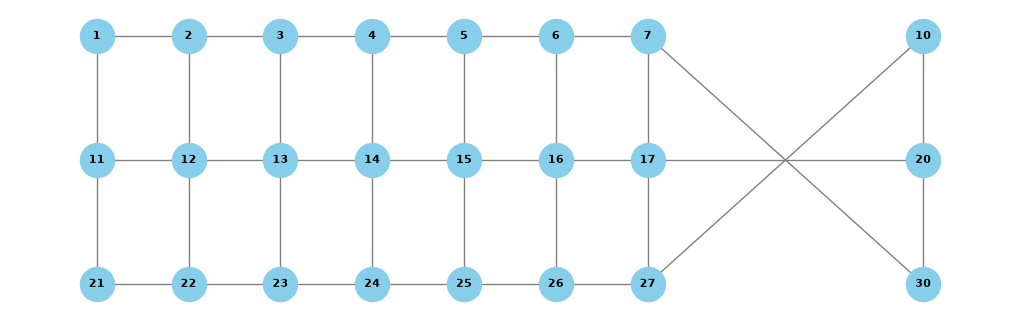

In [10]:
draw_graph(G_int, pos_int, (10,3))

##Flipping protocol: turn 3xn to 3xn-2 and flip corners
G_to_nminus2 = flipping_protocol(G_int, cols, show_graph= True, gridlock= True, plot_size = (10,3), position_int= pos_int)

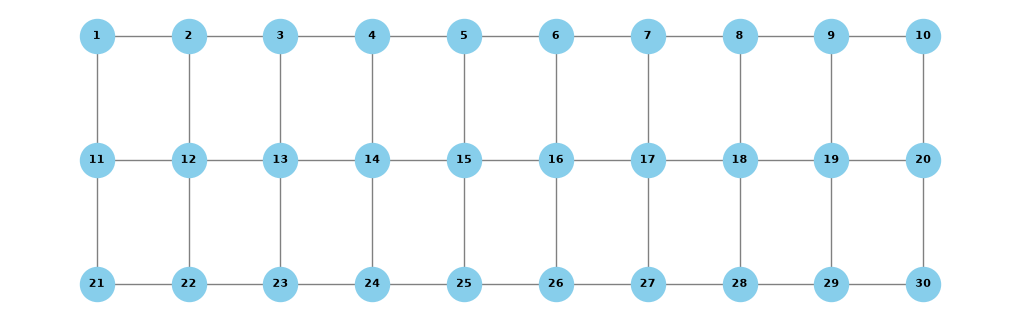

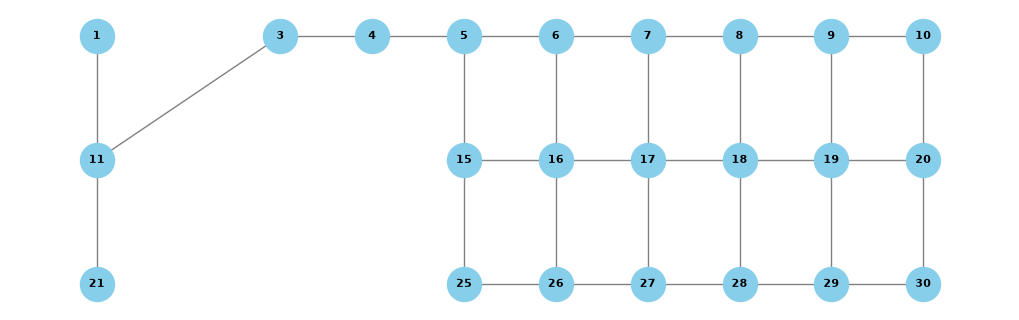

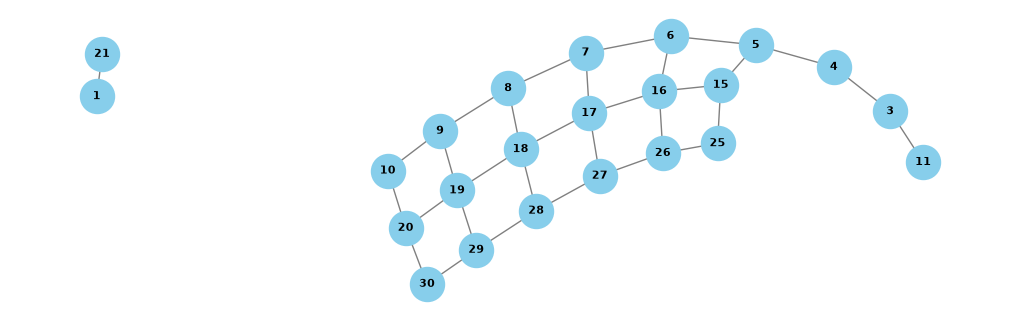

In [11]:
draw_graph(G_int, pos_int, (10,3))
##extract corners 
G3 = extract_corners(G_int, cols, show_graph= True, gridlock = True, plot_size= (10,3), position_int= pos_int)
draw_graph(G3, plot_size =(10,3))

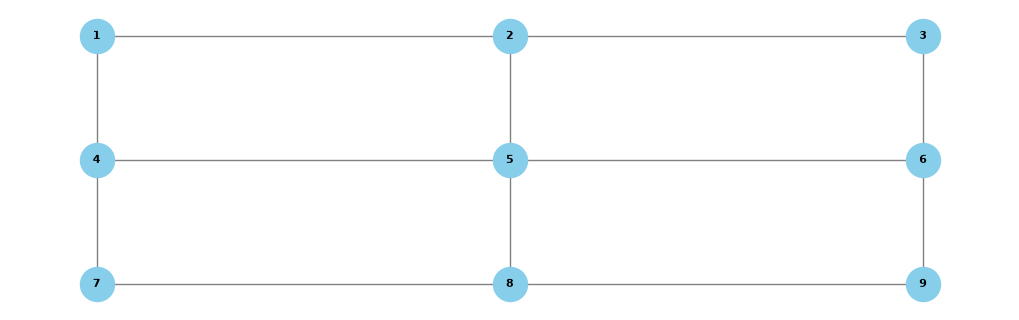

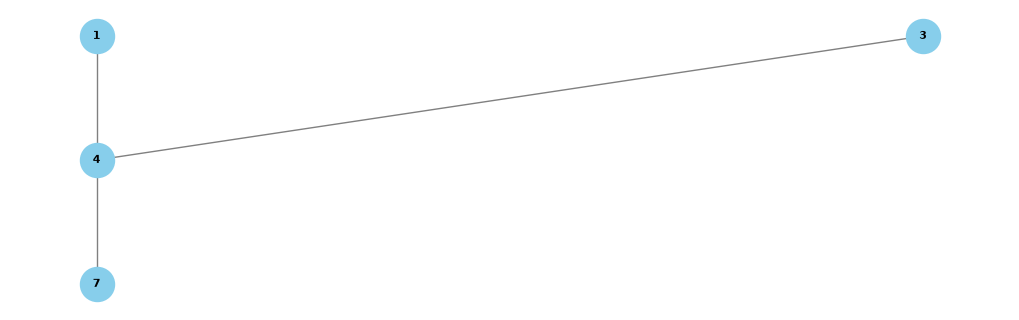

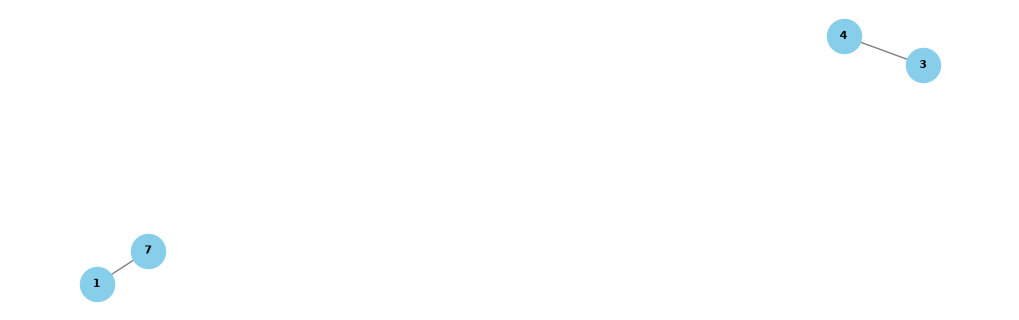

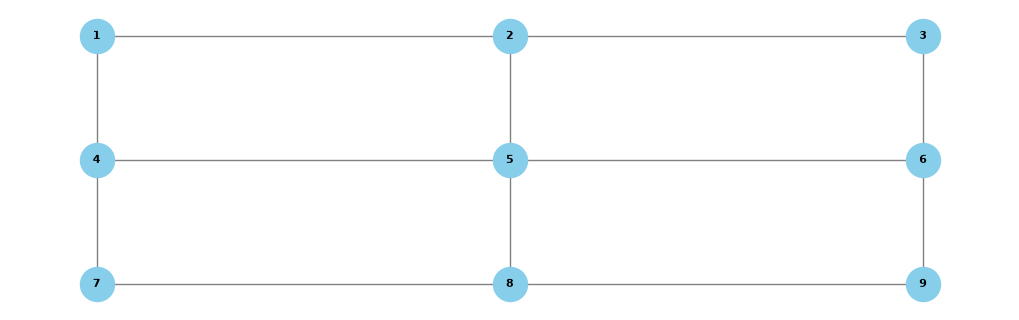

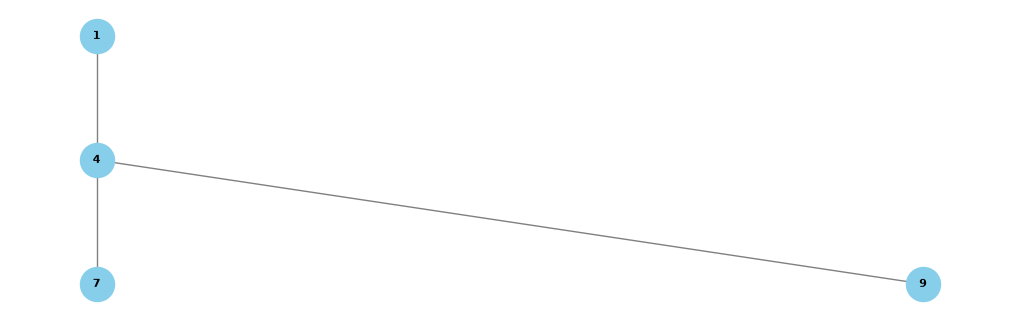

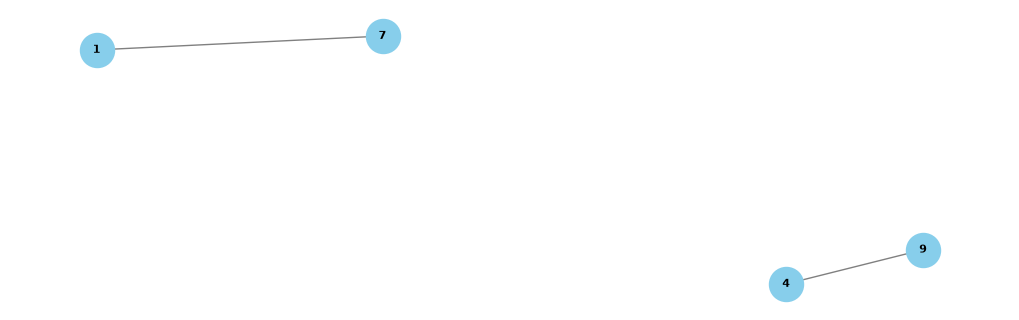

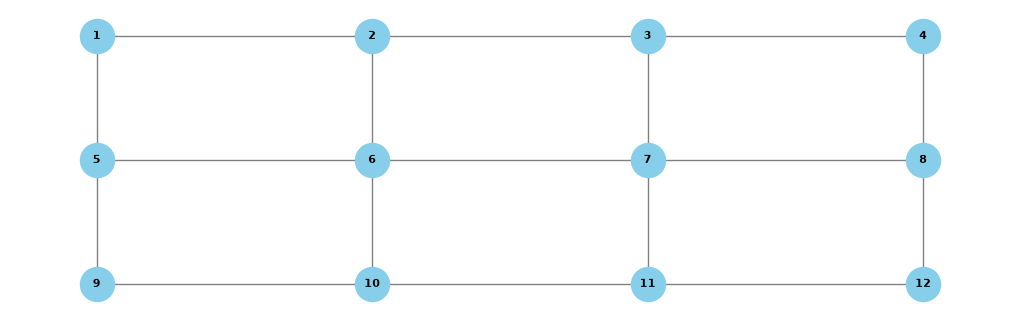

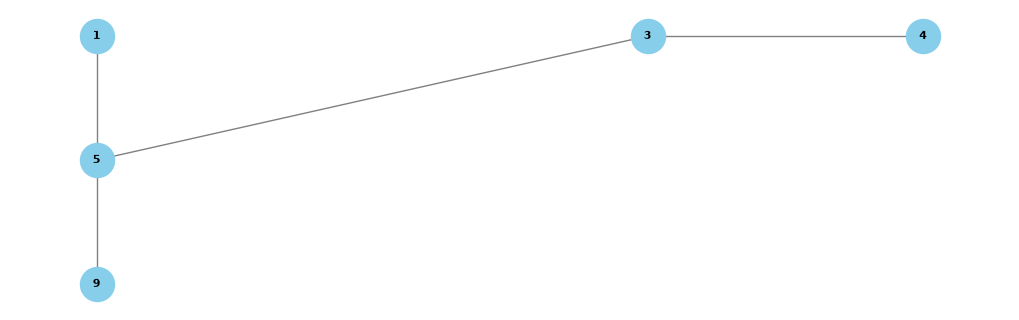

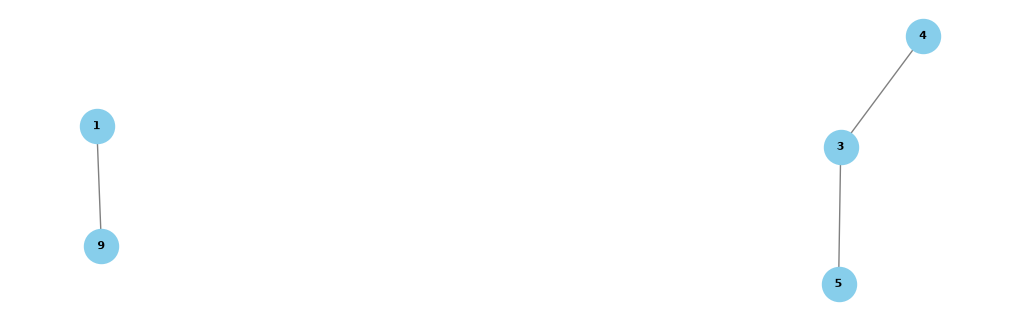

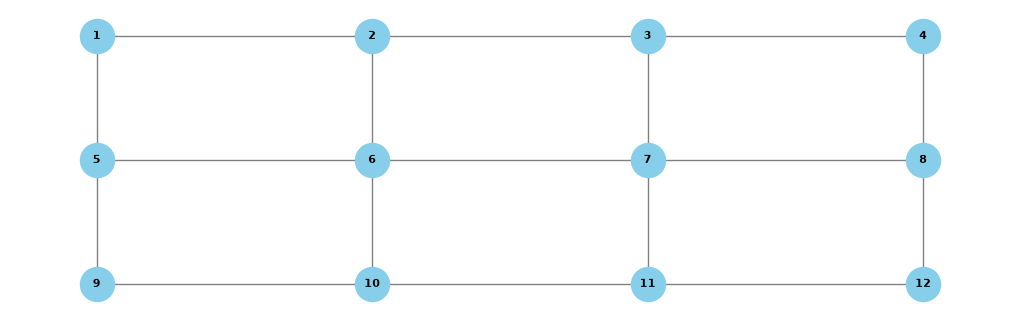

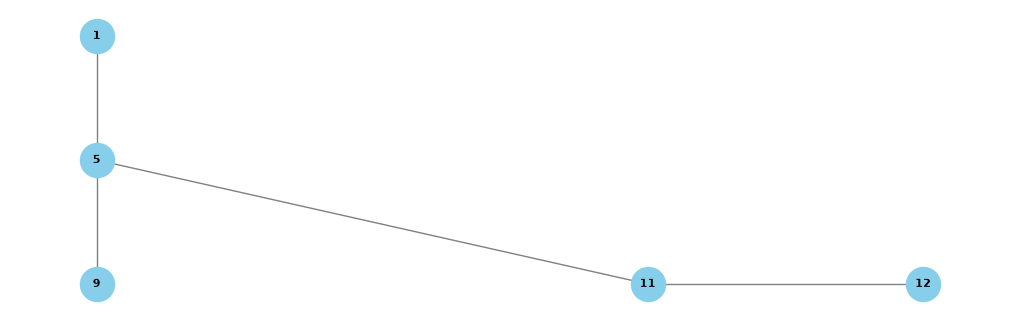

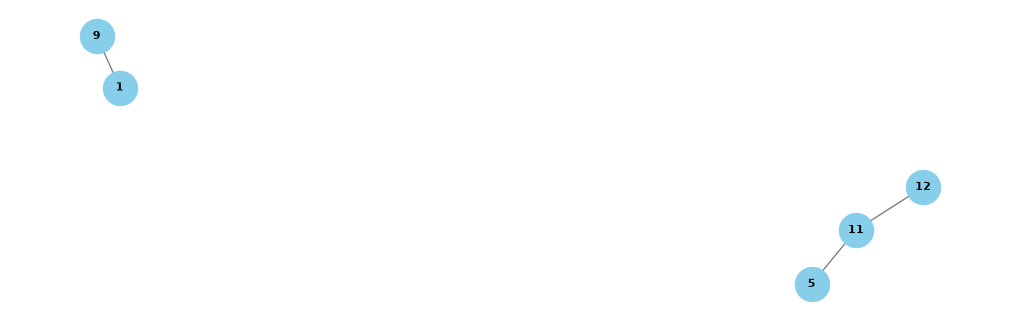

In [12]:
rows = 3
cols_3x3 = 3

G_3x3 = nx.grid_2d_graph(rows, cols_3x3)
G_3x3_int = nx.convert_node_labels_to_integers(G_3x3, first_label=1)
pos_3x3_int = convert_position_to_integers( G_3x3_int, cols_3x3)

#corner extraction on 3x3
draw_graph(G_3x3_int, pos_3x3_int, (10,3))
G4 = extract_corners(G_3x3_int, cols_3x3, show_graph= True, gridlock = True, plot_size= (10,3), position_int= pos_3x3_int)
draw_graph(G4, plot_size =(10,3))

#corner extraction on 3x3, inverted
draw_graph(G_3x3_int, pos_3x3_int, (10,3))
G5 = extract_corners(G_3x3_int, cols_3x3, show_graph= True, gridlock = True, plot_size= (10,3), 
                     position_int= pos_3x3_int, invert=True)
draw_graph(G5, plot_size =(10,3))

rows = 3
cols_3x4 = 4

G_3x4 = nx.grid_2d_graph(rows, cols_3x4)
G_3x4_int = nx.convert_node_labels_to_integers(G_3x4, first_label=1)
pos_3x4_int = convert_position_to_integers( G_3x4_int, cols_3x4)

#corner extraction on 3x4
draw_graph(G_3x4_int, pos_3x4_int, (10,3))
G6 = extract_corners(G_3x4_int, cols_3x4, show_graph= True, gridlock = True, plot_size= (10,3), position_int= pos_3x4_int)
draw_graph(G6, plot_size =(10,3))

#corner extraction on 3x4, inverted
draw_graph(G_3x4_int, pos_3x4_int, (10,3))
G7 = extract_corners(G_3x4_int, cols_3x4, show_graph= True, gridlock = True, plot_size= (10,3), position_int= pos_3x4_int
                    , invert= True)
draw_graph(G7, plot_size =(10,3))

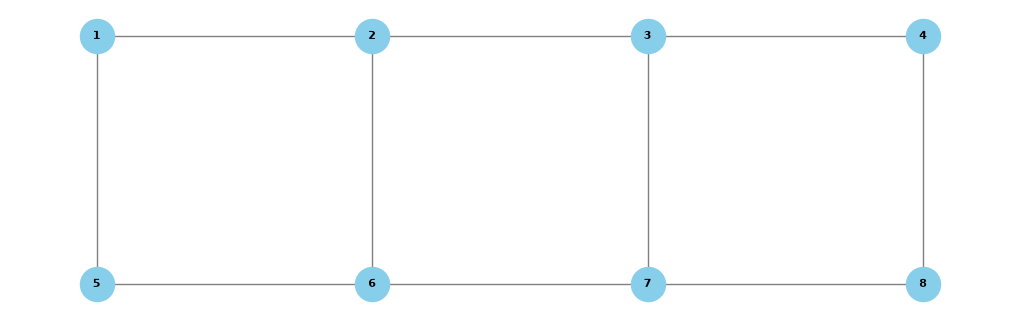

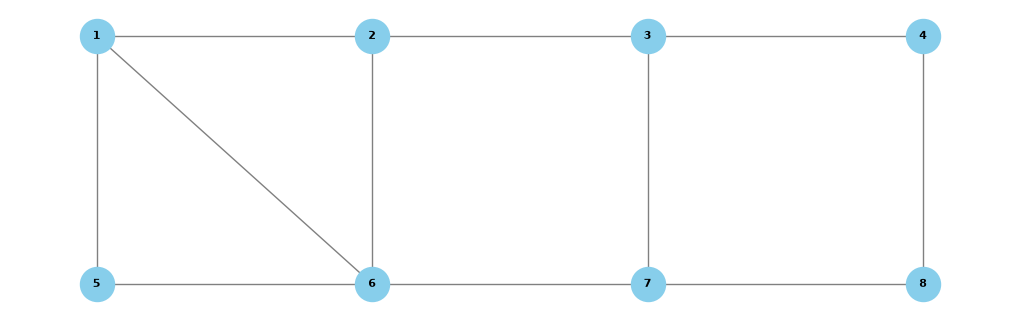

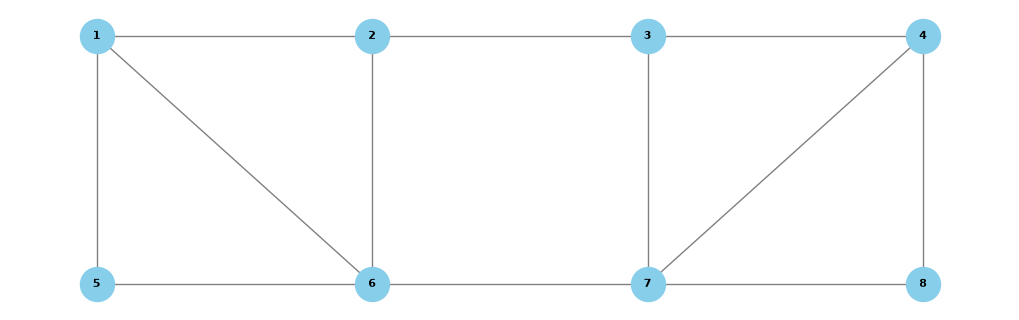

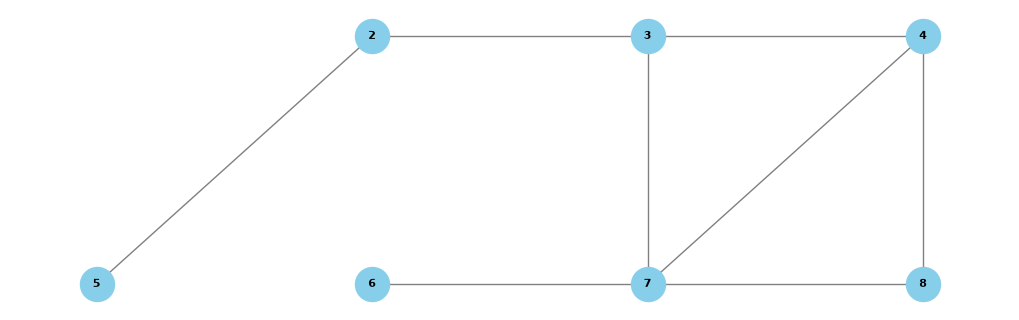

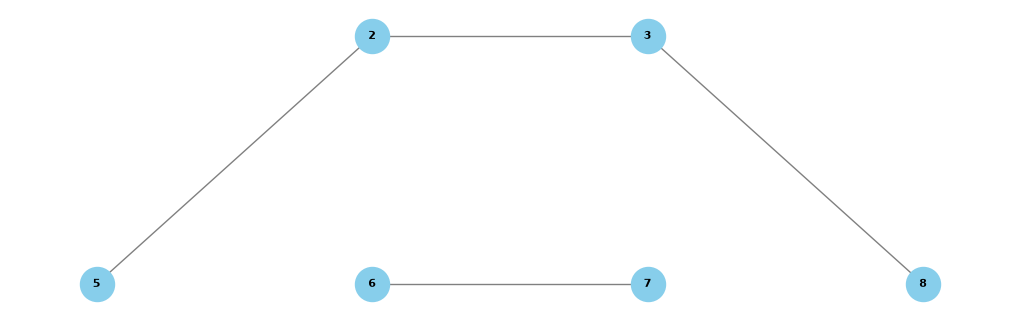

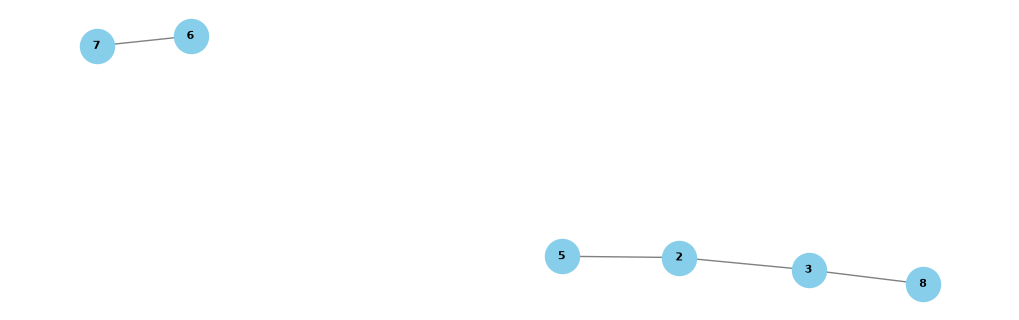

In [13]:
rows2 = 2
cols4 = 4

G_2x4 = nx.grid_2d_graph(rows2, cols4)

G_2x4_int = nx.convert_node_labels_to_integers(G_2x4, first_label=1)


pos_2x4_int = convert_position_to_integers(G_2x4_int, cols4)

draw_graph(G_2x4_int, pos_2x4_int, (10,3))


#nested bell pair, nx4
G8 = local_complementation_integers(5, G_2x4_int, show_graph= True, gridlock = True, plot_size= (10,3), position_int= pos_2x4_int)
G8 = local_complementation_integers(8, G8, show_graph= True, gridlock = True, plot_size= (10,3), position_int= pos_2x4_int)
G8 = Y_graph_operation(1, G8, show_graph= True, gridlock = True, plot_size= (10,3), position_int= pos_2x4_int)
G8 = Y_graph_operation(4, G8, show_graph= True, gridlock = True, plot_size= (10,3), position_int= pos_2x4_int)

draw_graph(G8, plot_size =(10,3))

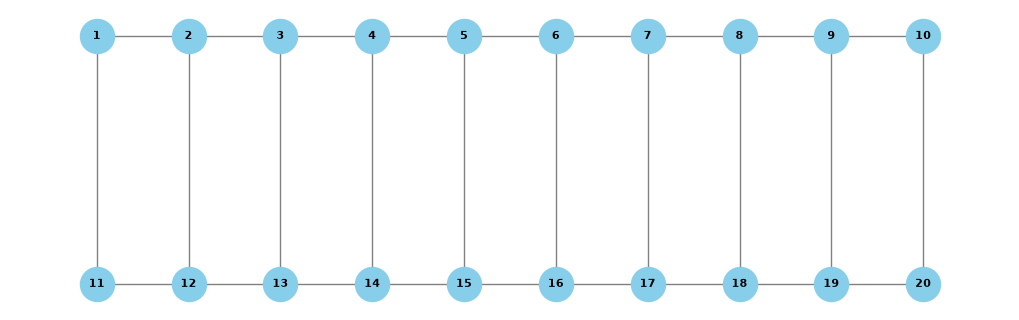

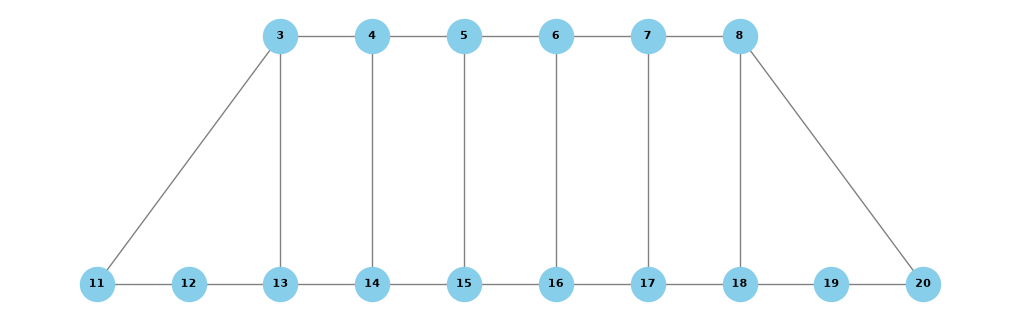

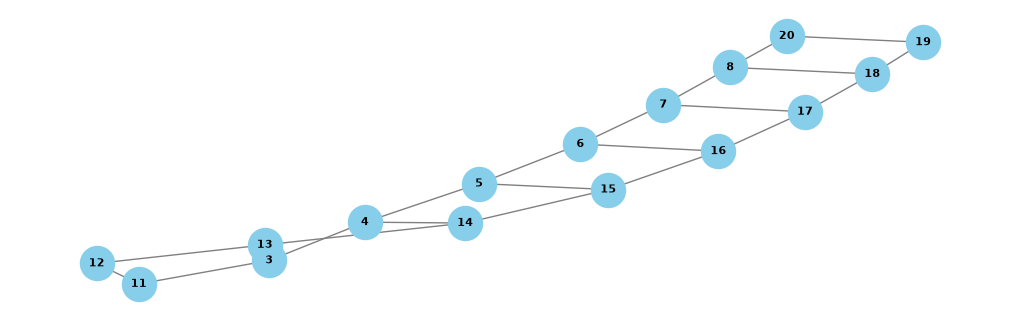

In [14]:
cols10 = 10
G_2x10 = nx.grid_2d_graph(rows2, cols10)
G_2x10_int = nx.convert_node_labels_to_integers(G_2x10, first_label=1)
pos_2x10_int = convert_position_to_integers(G_2x10_int, cols10)
draw_graph(G_2x10_int, pos_2x10_int, (10,3))

#corner folding protocol for nested bell pair
G9 = corner_folding_protocol(G_2x10_int, cols10, show_graph= True, gridlock = True, plot_size= (10,3), position_int= pos_2x10_int)
draw_graph(G9, plot_size =(10,3))


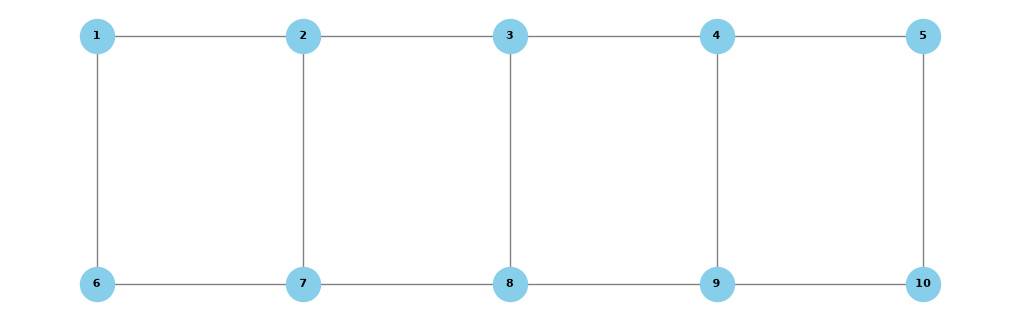

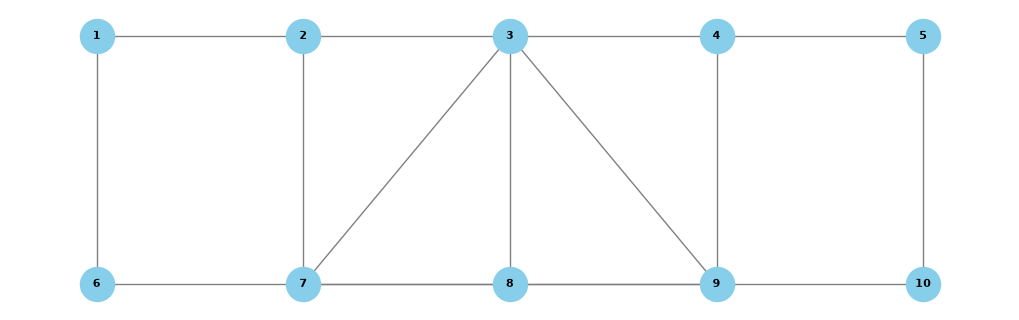

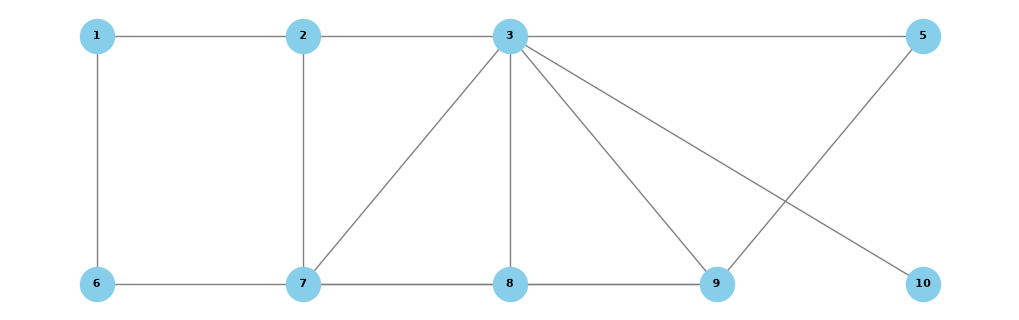

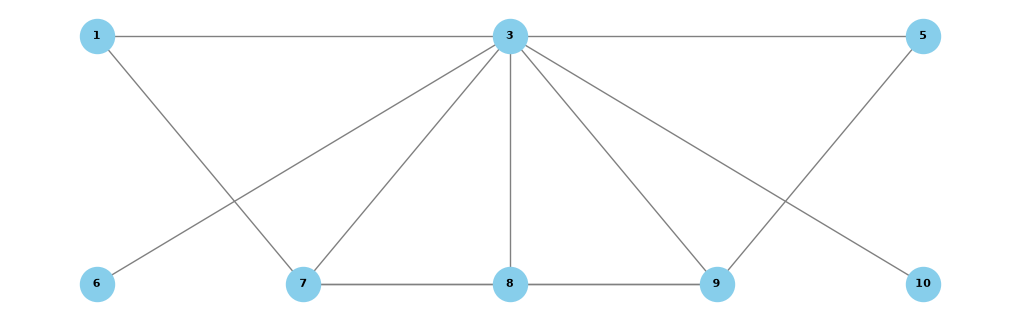

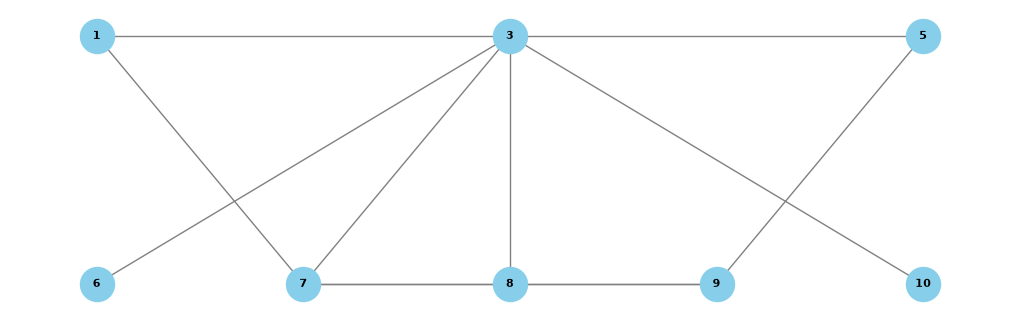

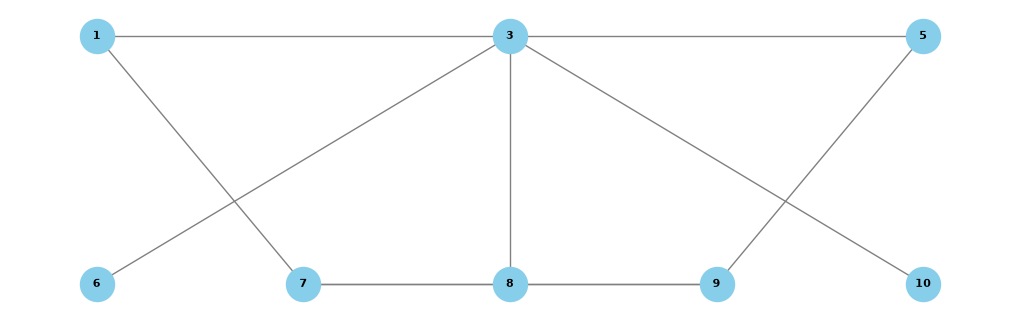

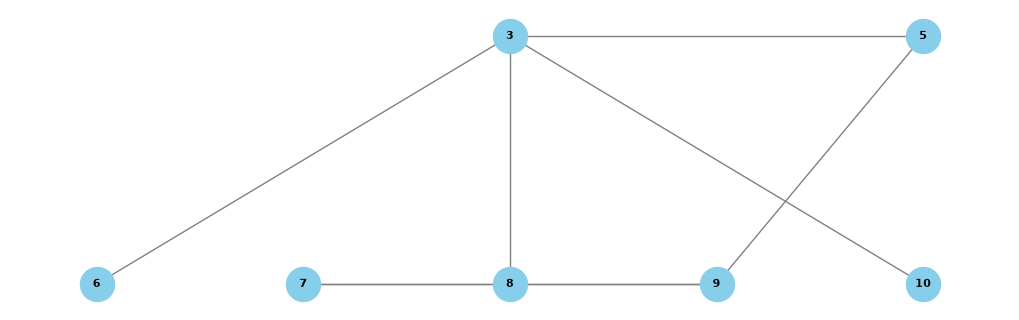

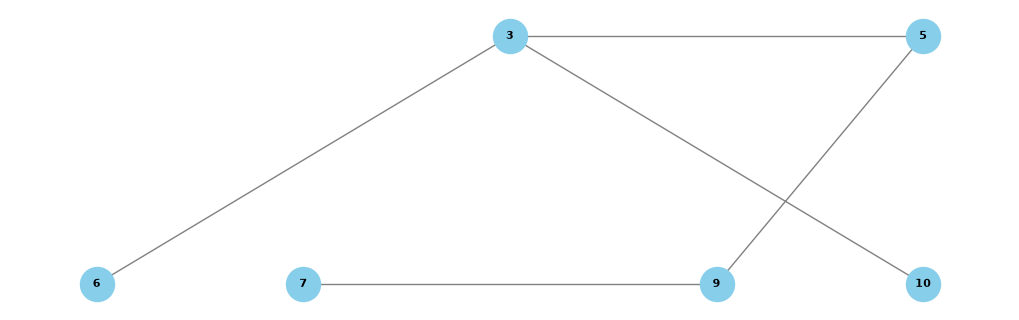

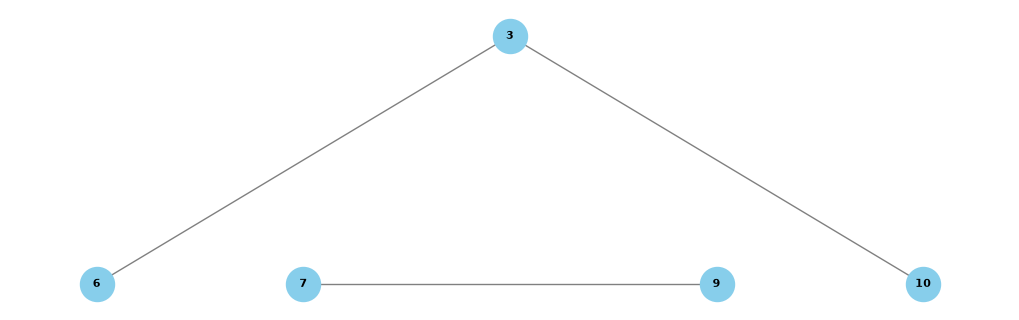

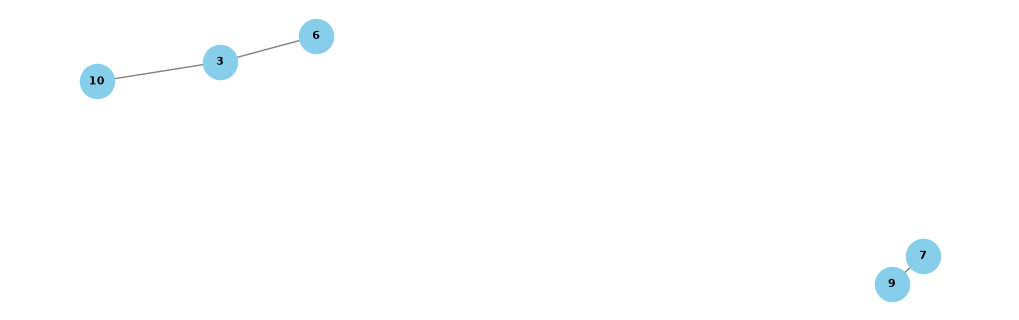

In [18]:
cols5 = 5
G_2x5 = nx.grid_2d_graph(rows2, cols5)
G_2x5_int = nx.convert_node_labels_to_integers(G_2x5, first_label=1)
pos_2x5_int = convert_position_to_integers(G_2x5_int, cols5)
draw_graph(G_2x5_int, pos_2x5_int, (10,3))

#corner folding protocol for nested bell pair, for b2 = b1 + 2
G9 = local_complementation_integers(8, G_2x5_int, show_graph= True, gridlock = True, plot_size= (10,3), position_int= pos_2x5_int)

G9 = X_graph_operation(4, G9, pivot = 5,show_graph= True, gridlock = True, plot_size= (10,3), position_int= pos_2x5_int)
G9 = X_graph_operation(2, G9, pivot = 1,show_graph= True, gridlock = True, plot_size= (10,3), position_int= pos_2x5_int)

G9 = local_complementation_integers(5, G9, show_graph= True, gridlock = True, plot_size= (10,3), position_int= pos_2x5_int)
G9 = local_complementation_integers(1, G9, show_graph= True, gridlock = True, plot_size= (10,3), position_int= pos_2x5_int)

G9 =Z_graph_operation(1, G9, show_graph= True, gridlock = True, plot_size= (10,3), position_int= pos_2x5_int)
G9 =Z_graph_operation(8, G9, show_graph= True, gridlock = True, plot_size= (10,3), position_int= pos_2x5_int)
G9 =Z_graph_operation(5, G9, show_graph= True, gridlock = True, plot_size= (10,3), position_int= pos_2x5_int)


draw_graph(G9, plot_size =(10,3))


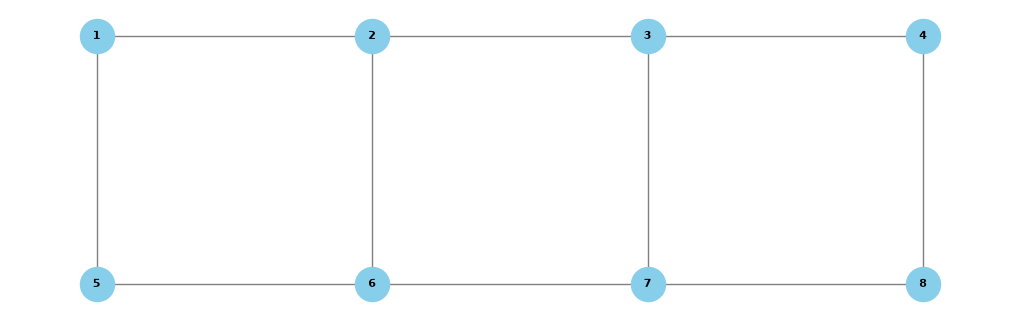

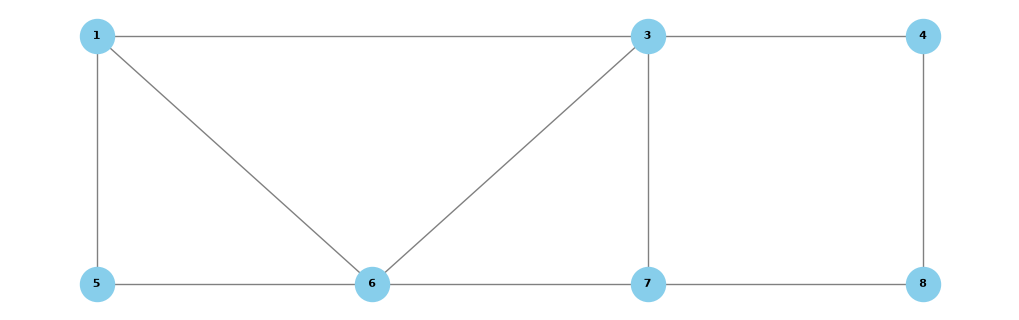

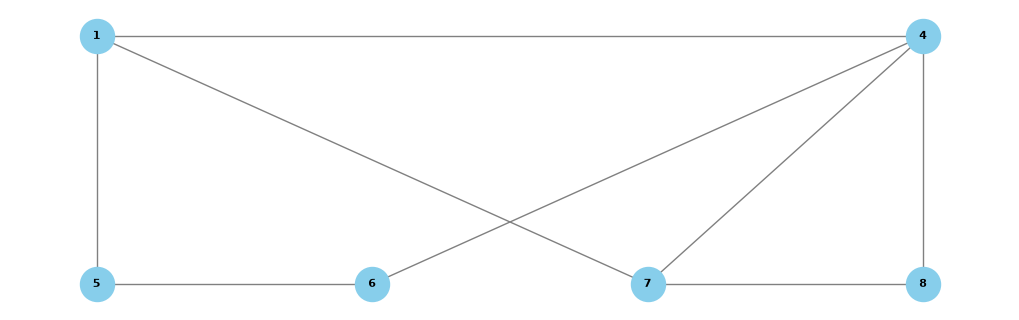

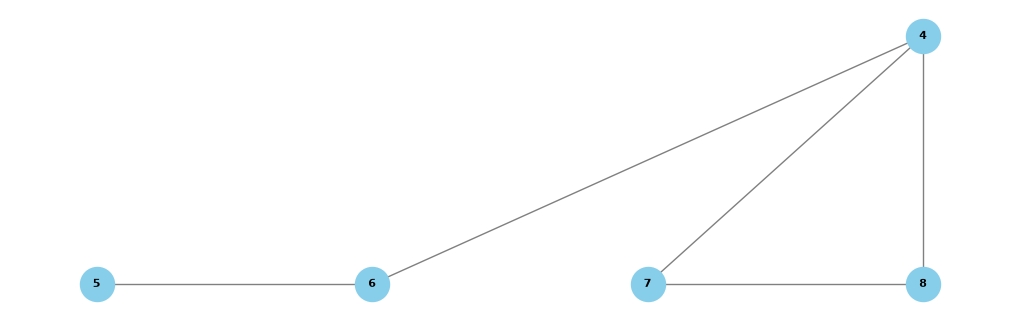

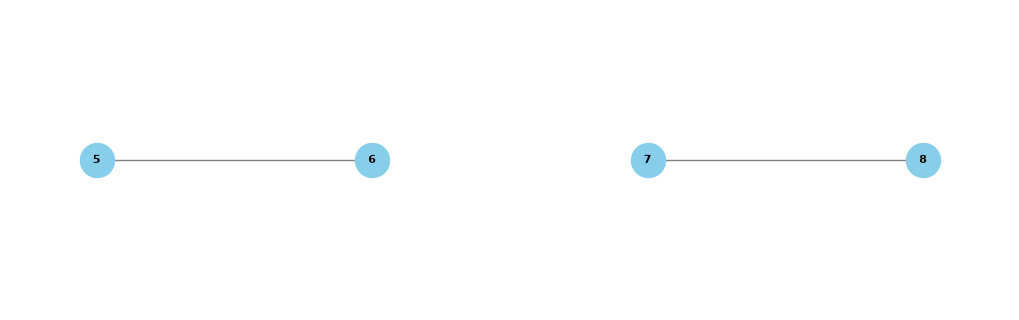

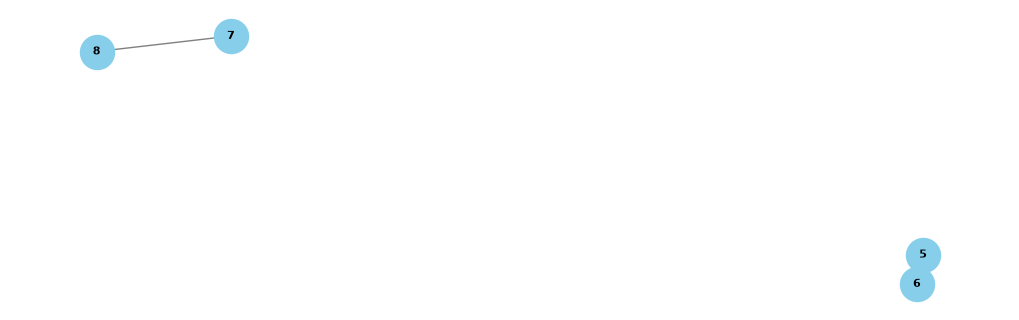

In [21]:
draw_graph(G_2x4_int, pos_2x4_int, (10,3))

#adjacent bell pair 
G10 = Y_graph_operation(2, G_2x4_int, show_graph= True, gridlock = True, plot_size= (10,3), position_int= pos_2x4_int)
G10 = Y_graph_operation(3, G10, show_graph= True, gridlock = True, plot_size= (10,3), position_int= pos_2x4_int)
G10= Z_graph_operation(1, G10, show_graph= True, gridlock = True, plot_size= (10,3), position_int= pos_2x4_int)
G10 = Z_graph_operation(4, G10, show_graph= True, gridlock = True, plot_size= (10,3), position_int= pos_2x4_int)


draw_graph(G10, plot_size =(10,3))

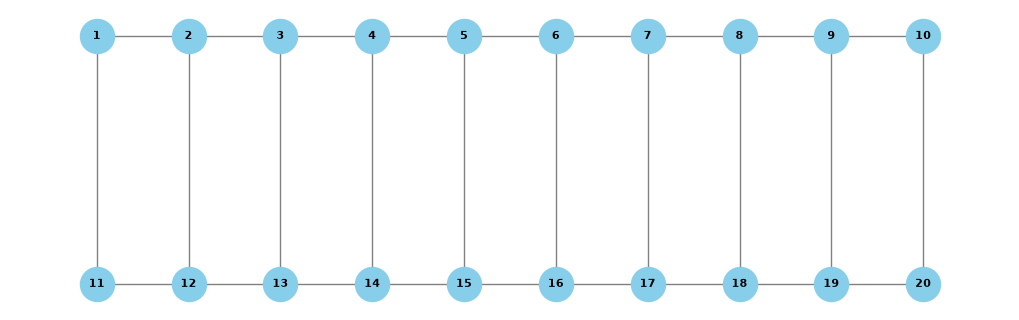

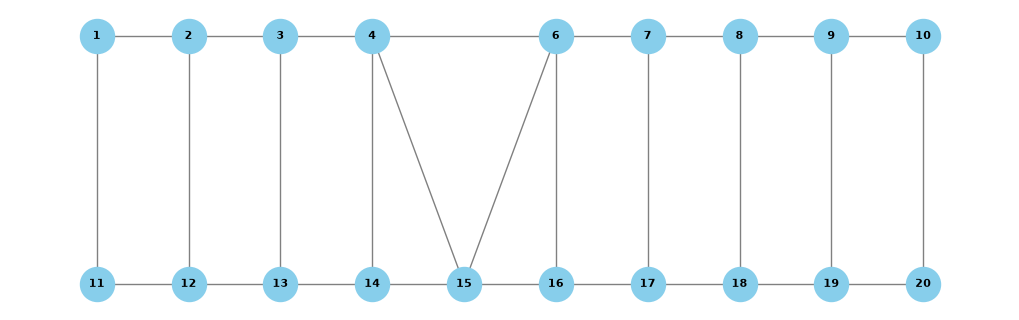

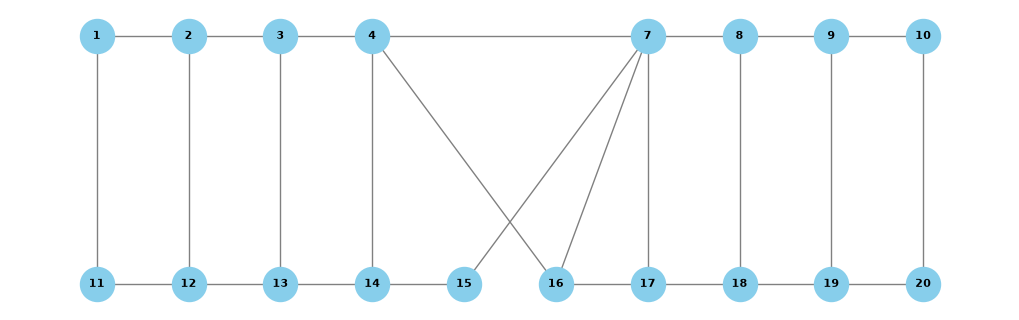

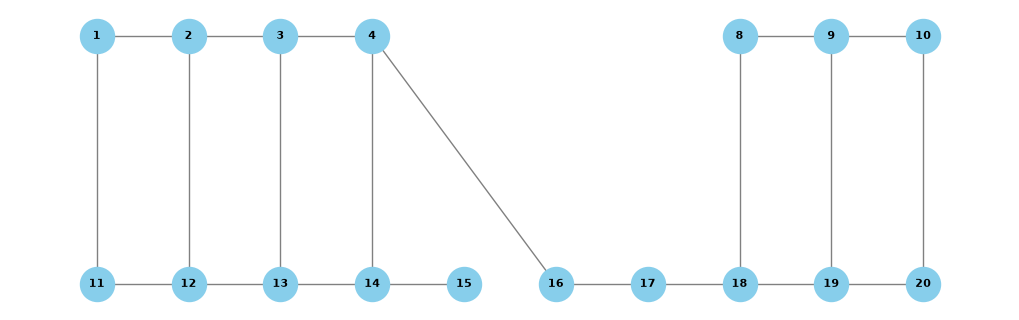

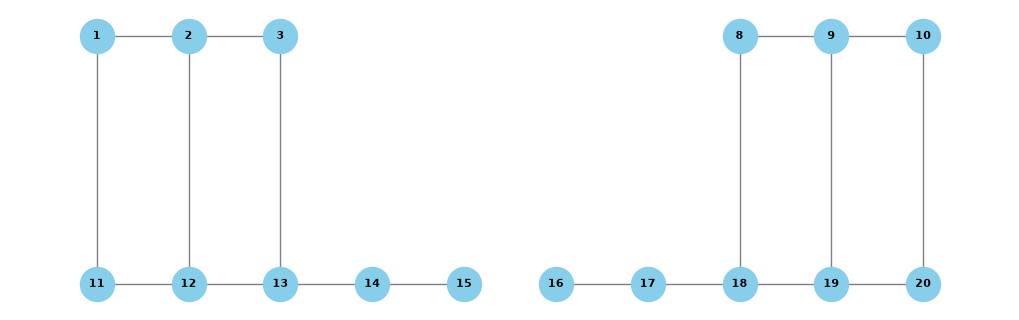

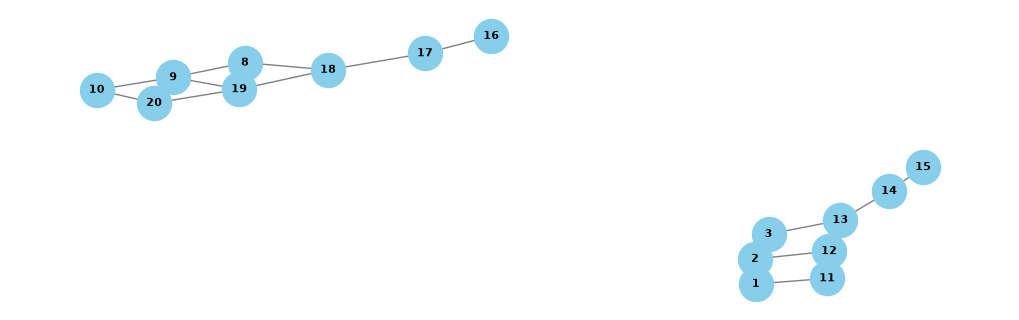

In [22]:
draw_graph(G_2x10_int, pos_2x10_int, (10,3))

#adjacent  bell pair 
G11 = Y_graph_operation(5, G_2x10_int, show_graph= True, gridlock = True, plot_size= (10,3), position_int= pos_2x10_int)
G11 = Y_graph_operation(6, G11, show_graph= True, gridlock = True, plot_size= (10,3), position_int= pos_2x10_int)
G11 = Z_graph_operation(7, G11, show_graph= True, gridlock = True, plot_size= (10,3), position_int= pos_2x10_int)
G11 = Z_graph_operation(4, G11, show_graph= True, gridlock = True, plot_size= (10,3), position_int= pos_2x10_int)


draw_graph(G11, plot_size =(10,3))